# What people ask Edmonton Open Data for, and what happens to it

**Dataset:** *Dataset Requests* (`a9w6-s3na`) on `data.edmonton.ca`. It is
refreshed daily and holds every request since automated intake began on
2016-01-26.

**Two jobs:**

1. **Duplicate check (§6).** Before this project sends a data request, find
   out whether someone has already asked for it and what the City answered.
2. **Landscape (§3–§5).** What people request over time, what gets published,
   and what gets refused or left open.

⚠️ **Read §2 before quoting any count.** The table mixes two intake systems
with different status vocabularies. In December 2023, 126 old requests that
had never been decided were moved to the new tracker, and on the old system
they were stamped `Rejected` or `Declined` as they went. A single-day bulk
edit in August 2026 also reset `status_date` on 241 rows, and two 2023
clean-up days declined 16 requests from 2016 about seven years late.
Counted naively, the table double-counts requests, **overstates decided
refusals by more than 3×**, and misdates decisions.

## Reproducing

```
pip install pandas matplotlib certifi
```

Public endpoint, no API token.

In [1]:
import json
import re
import ssl
import urllib.parse
import urllib.request
from datetime import datetime, timezone

import certifi
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

UA = "edmonton-tax-viz/dataset-requests (open-data landscape)"
SSL_CTX = ssl.create_default_context(cafile=certifi.where())
RUN_AT = datetime.now(timezone.utc)
REQUESTS = "a9w6-s3na"
LIMIT = 50000

pd.set_option("display.max_colwidth", 90, "display.width", 200)

CHECKS: list[tuple[bool, str]] = []


def check(ok: bool, claim: str) -> None:
    CHECKS.append((bool(ok), claim))
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")


def soda(dataset: str, params: dict) -> list[dict]:
    url = (f"https://data.edmonton.ca/resource/{dataset}.json?"
           + urllib.parse.urlencode(params))
    req = urllib.request.Request(url, headers={"User-Agent": UA})
    with urllib.request.urlopen(req, context=SSL_CTX, timeout=120) as r:
        return json.loads(r.read())


raw = pd.DataFrame(soda(REQUESTS, {"$limit": LIMIT}))
d = raw.copy()
for c in ["request_creation_date", "status_date", "dataset_published_date"]:
    d[c] = pd.to_datetime(d[c])
d["department"] = d["department"].fillna("(blank)")

display(Markdown(f"**Snapshot.** Executed against live data **{RUN_AT:%Y-%m-%d}** "
                 f"(UTC): **{len(d):,} requests**, created "
                 f"{d.request_creation_date.min():%Y-%m-%d} to "
                 f"{d.request_creation_date.max():%Y-%m-%d}. The source changes "
                 "daily, so re-execute before citing a figure."))
check(len(d) < LIMIT, f"one page holds the whole table ({len(d)} < {LIMIT}), so no rows were cut off")
check(d.request_number.is_unique, "request_number is unique")

**Snapshot.** Executed against live data **2026-09-23** (UTC): **656 requests**, created 2016-01-26 to 2026-08-19. The source changes daily, so re-execute before citing a figure.

  [PASS] one page holds the whole table (656 < 50000), so no rows were cut off
  [PASS] request_number is unique


## 1. Two intake systems, two status vocabularies

`request_number` gives away which system took the request:

* **`ODRyy-nnn`**: the original intake, from 2016 until its last entry in
  2024. Statuses are Title-case: `Completed`, `Rejected`, `Declined`,
  `Cancelled`, `New`.
* **Opaque ids such as `868…`**: the newer tracker, from October 2021 on.
  Statuses are UPPER-case: `NEW`, `IN PROGRESS`, `PAUSED`, `CLOSED`.

⚠️ **The newer system has no way to say "refused" and no way to say
"published".** Everything that ends goes to `CLOSED`. Old-system outcomes
therefore can't be compared one-for-one with new-system outcomes, and
`CLOSED` is shown below as its own bucket instead of being folded into
"done".

In [2]:
d["system"] = d.request_number.str.startswith("ODR").map({True: "ODR (old)", False: "tracker (new)"})
print(pd.crosstab(d.status, d.system, margins=True))
print()
print(d.groupby("system").request_creation_date.agg(["min", "max", "count"]))

OUTCOME = {
    "Completed": "Completed",
    "Rejected": "Refused", "Declined": "Refused",
    "CLOSED": "Closed (reason not given)",
    "NEW": "Open", "New": "Open", "IN PROGRESS": "Open", "PAUSED": "Open",
    "Cancelled": "Withdrawn",
}
d["outcome"] = d.status.map(OUTCOME)
unmapped = sorted(d.loc[d.outcome.isna(), "status"].unique())
check(not unmapped, f"every status maps to an outcome bucket (unmapped: {unmapped or 'none'})")
d["outcome"] = d.outcome.fillna("Unmapped")

system       ODR (old)  tracker (new)  All
status                                    
CLOSED               0            152  152
Cancelled           19              0   19
Completed          146              0  146
Declined            50              0   50
IN PROGRESS          0             24   24
NEW                  0             92   92
New                  1              0    1
PAUSED               0             18   18
Rejected           154              0  154
All                370            286  656

                              min                 max  count
system                                                      
ODR (old)     2016-01-26 15:32:27 2024-09-06 15:40:23    370
tracker (new) 2021-10-29 09:30:13 2026-08-19 15:37:21    286
  [PASS] every status maps to an outcome bucket (unmapped: none)


### `dataset_published_date` on a `CLOSED` row does not mean something was published

Every `CLOSED` row has a `dataset_published_date`, including requests the
City could not have fulfilled publicly. One example is below. On the new
tracker the field is best read as "date closed".

In [3]:
closed = d[d.status == "CLOSED"]
check(closed.dataset_published_date.notna().all(),
      f"all {len(closed)} CLOSED rows carry a dataset_published_date")
ex = d[d.request_details.fillna("").str.contains("will not be publicly visible")]
print(ex[["request_number", "status", "dataset_published_date", "request_description", "request_details"]].to_string(index=False))

  [PASS] all 152 CLOSED rows carry a dataset_published_date
request_number status dataset_published_date                                                                        request_description                                                                                                                                                                       request_details
     8688a6173 CLOSED    2024-06-14 15:17:57 Property and Education Tax Rates prior to 2014 and as far back as available, ideally 1960? This information is requested to perform modeling of historical changes to the assessment values of properties before 2014. This is a private study and will not be publicly visible.
     8688a6366 CLOSED    2024-06-14 15:17:12                                         Historical Property Assessment Data prior to 2012.                                                                                                                Ideally between 1960 and 2012, this data will not be publ

## 2. Two artifacts that distort naive counts

### 2a. The December 2023 migration: "Rejected" here means "moved"

On 2023-12-12 and 2023-12-13, old-system requests were re-entered in the new
tracker under new ids and new creation dates. On the **same two days**, their
old-system rows were set to `Rejected` or `Declined`. The pairs are matched
by normalised title, restricted to old rows whose `status_date` falls on
those two days.

These were **not refusals**. The request carried on in the new tracker, and
many are still open there. Most had been created years earlier with no
status change since, so they had simply **never been decided**. Taking the
old status at face value overstates refusals.

The notebook handles the pairs as follows:

* **Volume over time:** each pair is counted once, in the year the request
  was first made. The new-tracker row is dropped.
* **Outcome:** the old row takes its outcome from the new-tracker row, which
  is where the request actually stands now. A `moved` flag records that it
  was never decided on the old system.

In [4]:
norm = lambda s: re.sub(r"[^a-z0-9]", "", str(s).lower())
d["title_key"] = d.request_description.map(norm)
MIGRATION_DAYS = {"2023-12-12", "2023-12-13"}
on_migration_day = d.status_date.dt.strftime("%Y-%m-%d").isin(MIGRATION_DAYS)
created_on_migration_day = d.request_creation_date.dt.strftime("%Y-%m-%d").isin(MIGRATION_DAYS)

odr_stamped = d[(d.system == "ODR (old)") & on_migration_day]
new_side = d[(d.system == "tracker (new)") & created_on_migration_day]
pairs = odr_stamped.merge(new_side, on="title_key", suffixes=("_orig", ""))
check(pairs.request_number_orig.is_unique and pairs.request_number.is_unique,
      f"migration pairs match one-to-one by title ({len(pairs)} pairs)")

d["reintake"] = d.request_number.isin(pairs.request_number)
d["moved"] = d.request_number.isin(pairs.request_number_orig)
d.loc[d.moved, "outcome"] = d.loc[d.moved, "request_number"].map(
    pairs.set_index("request_number_orig").outcome)

print(f"old-system rows stamped on the migration days: {len(odr_stamped)}")
print(f"  ...of which paired with a new-tracker row:    {len(pairs)}")
print("\nOld-system stamp  ×  where the request stands now (new tracker):")
print(pd.crosstab(pairs.status_orig, pairs.status, margins=True))
print("\nOld-system creation year of the moved requests:")
print(pairs.request_creation_date_orig.dt.year.value_counts().sort_index().to_string())
check(len(pairs) >= 100, f"the Dec-2023 migration is still visible ({len(pairs)} pairs)")
check(len(odr_stamped) - len(pairs) <= 2,
      f"nearly every old row stamped on the migration days was moved "
      f"({len(pairs)} of {len(odr_stamped)}), so the stamp means 'moved', not 'refused'")
check(set(odr_stamped.status) <= {"Rejected", "Declined"},
      "every migration-day stamp is Rejected/Declined, the statuses a naive reading counts as refusals")

  [PASS] migration pairs match one-to-one by title (126 pairs)
old-system rows stamped on the migration days: 127
  ...of which paired with a new-tracker row:    126

Old-system stamp  ×  where the request stands now (new tracker):
status       CLOSED  IN PROGRESS  NEW  PAUSED  All
status_orig                                       
Declined         10            7    6       0   23
Rejected         43            7   49       4  103
All              53           14   55       4  126

Old-system creation year of the moved requests:
request_creation_date_orig
2016    11
2017    27
2018    21
2019    24
2020    17
2021     5
2022    10
2023    11
  [PASS] the Dec-2023 migration is still visible (126 pairs)
  [PASS] nearly every old row stamped on the migration days was moved (126 of 127), so the stamp means 'moved', not 'refused'
  [PASS] every migration-day stamp is Rejected/Declined, the statuses a naive reading counts as refusals


### 2b. `status_date` is the date the row was last edited, not the date of the decision

Large blocks of rows share a single `status_date`. That is a bulk edit, not
hundreds of decisions made on one day. Durations such as "time to decision"
computed from `status_date` are therefore unreliable on the new tracker, and
this notebook doesn't compute them.

In [5]:
top_days = d.status_date.dt.date.value_counts().head(5)
print(top_days)
biggest = top_days.index[0]
print(f"\n{biggest}: statuses on the bulk-edit day")
print(d[d.status_date.dt.date == biggest].status.value_counts())
check(top_days.iloc[0] >= 100, f"a bulk status_date sweep is present ({top_days.iloc[0]} rows on {biggest})")

status_date
2026-08-19    241
2023-12-13    104
2026-08-26     32
2023-12-12     23
2023-09-19     16
Name: count, dtype: int64

2026-08-19: statuses on the bulk-edit day
status
CLOSED         139
NEW             62
IN PROGRESS     24
PAUSED          16
Name: count, dtype: int64
  [PASS] a bulk status_date sweep is present (241 rows on 2026-08-19)


### 2c. Two 2023 clean-up days, and a test row

`status_date` spikes also sit inside the old system's refusals. On
2023-06-07 and 2023-09-19, requests made in 2016 were declined in batches,
about seven years after they were asked. That is backlog housekeeping, not a
considered refusal, so §5 counts those rows as **closed in a clean-up sweep**
instead of refused. A row is swept only if it was declined on one of those
days **and** more than a year after it was made; a request refused the day
after it arrived is still a refusal.

One row is titled `test` with details `test`. It is removed from every count
below and printed here.

In [6]:
SWEEP_DAYS = {"2023-06-07", "2023-09-19"}
d["swept"] = ((d.system == "ODR (old)") & d.status.isin(["Rejected", "Declined"])
              & d.status_date.dt.strftime("%Y-%m-%d").isin(SWEEP_DAYS)
              & ((d.status_date - d.request_creation_date).dt.days > 365))
print(d[d.swept].groupby([d.status_date.dt.date, d.request_creation_date.dt.year]).size().to_string())
check(d.swept.sum() >= 10, f"the 2023 clean-up sweeps are still visible ({d.swept.sum()} rows)")
test_rows = d[d.request_description.fillna("").str.strip().str.lower().eq("test")
              & d.request_details.fillna("").str.strip().str.lower().isin(["test", ""])]
print("\nremoved as test entries:")
print(test_rows[["request_number", "status", "request_description", "request_details"]].to_string(index=False))

status_date  request_creation_date
2023-06-07   2016                      5
2023-09-19   2016                     11
  [PASS] the 2023 clean-up sweeps are still visible (16 rows)

removed as test entries:
request_number   status request_description request_details
     ODR19-269 Rejected                test            test


## 3. Volume over time

Requests by the year they were **first** made, each counted once (§2a).
Colours show each request's current outcome. Moved requests show where they
stand on the new tracker.

outcome,Completed,Refused,Closed (reason not given),Open,Withdrawn,total
year,,,,,,
2016,46,40,6,5,14,111
2017,28,6,16,11,1,62
2018,26,1,5,16,3,51
2019,17,8,8,16,1,50
2020,14,8,6,11,0,39
2021,10,1,7,4,0,22
2022,2,4,7,7,0,20
2023,3,9,23,12,0,47
2024,0,0,33,22,0,55


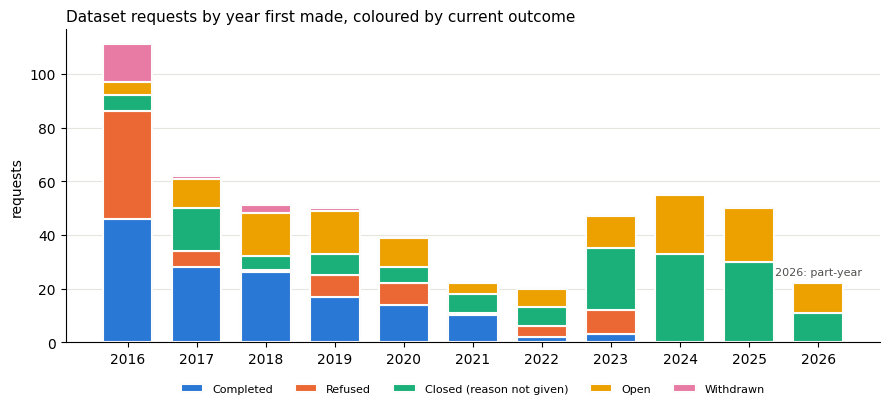

In [7]:
u = d[~d.reintake & ~d.request_number.isin(test_rows.request_number)].copy()
u["year"] = u.request_creation_date.dt.year
ORDER = ["Completed", "Refused", "Closed (reason not given)", "Open", "Withdrawn"]
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]  # dataviz reference palette, slots 1-5 in order
by_year = pd.crosstab(u.year, u.outcome).reindex(columns=ORDER, fill_value=0)
display(by_year.assign(total=by_year.sum(axis=1)))

fig, ax = plt.subplots(figsize=(9, 4.2))
bottom = pd.Series(0, index=by_year.index)
for col, colour in zip(ORDER, COLOURS):
    ax.bar(by_year.index, by_year[col], bottom=bottom, color=colour, label=col,
           width=0.72, edgecolor="#fcfcfb", linewidth=1.5)
    bottom += by_year[col]
ax.set_title("Dataset requests by year first made, coloured by current outcome", loc="left", fontsize=11)
ax.set_ylabel("requests")
ax.set_xticks(by_year.index)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e6e5e0", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.1))
this_year = RUN_AT.year
ax.annotate(f"{this_year}: part-year", (this_year, by_year.loc[this_year].sum() if this_year in by_year.index else 0),
            textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="#52514e")
plt.tight_layout()
plt.show()

**How to read it:**

* 2016 was the intake's first year and is its busiest. Only 11 of its rows
  are hackathon whiteboard captures (measured 2026-09-22), so hackathons
  don't explain the peak.
* Everything filed after the switch to the new tracker is either
  `Closed (reason not given)` or still `Open`. The drop in blue and orange
  after 2022 comes from the vocabulary change in §1. It is not a change in
  how the City decides.
* Green and yellow before 2021 are the moved requests: they were never
  decided on the old system, and they now sit on the new tracker.

## 4. What people request

Topics are assigned by keyword over title and details. Each request goes to
the **first** topic in the list below that matches, so every request is
counted once. This is a transparent heuristic, not a classifier, and the
patterns are printed so they can be argued with.

In [8]:
TOPICS = [
    ("Transit", r"\bets\b|transit|\bbus(?:es)?\b|lrt|gtfs|arc card|ridership|\btrain"),
    ("Property, assessment & tax", r"assess|parcel|propert|\btax|\blot\b|lot size|title"),
    ("Planning, permits & zoning", r"permit|zoning|land use|development|bylaw \d|\barp\b|rezon|licen[cs]e"),
    ("Roads, traffic & mobility", r"road|traffic|collision|speed|parking|snow|sidewalk|bike|cycl|pathway|pedestrian|intersection|radar|scooter|micromobility|bridge|pedway"),
    ("Utilities & drainage", r"drain|sewer|water|epcor|\bgas\b|power|electric|utilit"),
    ("Public safety", r"crime|police|fire|911|emergenc|bylaw enforcement|complain"),
    ("Parks, trees & environment", r"\bpark|\btrees?\b|green|waste|garbage|trash|recycl|climate|emission|river|ravine|natural area|cemeter|washroom|picnic|graffiti|ashtray|flood"),
    ("Recreation, library & community", r"recreation|library|leisure|community|arena|pool|school|playground"),
    ("People & census", r"census|population|demograph|income|housing|homeless|senior"),
    ("Budget & spending", r"budget|spend|\bcost|expend|revenue|contract|procure|salar|financial statement|expense|severance|capital project|renewal invest|funding|earnings"),
    ("Council, elections & administration", r"council|election|\bward|voting|candidate|meeting|motion|agenda|lobby|foip|\b311\b|job|rfp|disclosure"),
    ("Base maps & imagery", r"lidar|orthophoto|imagery|elevation|\bdem\b|postal code|neighbou?rhood (?:dataset|boundar)|manhole|historic resource"),
]


def topic_of(text: str) -> str:
    t = text.lower()
    for name, pat in TOPICS:
        if re.search(pat, t):
            return name
    return "Other / unclassified"


u["text"] = u.request_description.fillna("") + " " + u.request_details.fillna("")
u["topic"] = u.text.map(topic_of)
u["era"] = pd.cut(u.year, [2015, 2019, 2022, 2100], labels=["2016–19", "2020–22", "2023–now"])
tt = pd.crosstab(u.topic, u.era, margins=True, margins_name="all").sort_values("all", ascending=False)
display(tt)
print(f"unclassified: {(u.topic == 'Other / unclassified').mean():.0%} of requests")

era,2016–19,2020–22,2023–now,all
topic,,,,
all,274,81,174,529
Other / unclassified,50,18,24,92
"Roads, traffic & mobility",53,10,18,81
"Property, assessment & tax",25,6,31,62
"Planning, permits & zoning",24,13,19,56
"Council, elections & administration",24,5,13,42
"Parks, trees & environment",20,7,10,37
Utilities & drainage,19,9,8,36
Transit,12,4,14,30


unclassified: 17% of requests


## 5. What gets through, what gets refused, what never gets decided

### 5a. Old system, by the year a request was first made

The old system is the only one that records an explicit outcome. Each old
request lands in one of four groups:

* **Completed**
* **Refused**: `Rejected` or `Declined`, excluding the migration stamps
* **Never decided**: moved to the new tracker in December 2023
* **Closed in a clean-up sweep**: declined years late on a 2023 sweep day (§2c)
* **Withdrawn / still open**

In [9]:
old = u[u.system == "ODR (old)"].copy()
old["fate"] = "Withdrawn / still open"
old.loc[old.status == "Completed", "fate"] = "Completed"
old.loc[old.outcome == "Refused", "fate"] = "Refused"
old.loc[old.moved, "fate"] = "Never decided (moved)"
old.loc[old.swept, "fate"] = "Clean-up sweep"
FATES = ["Completed", "Refused", "Never decided (moved)", "Clean-up sweep", "Withdrawn / still open"]
fy = pd.crosstab(old.year, old.fate).reindex(columns=FATES, fill_value=0)
fy["completed share"] = (fy.Completed / fy[FATES].sum(axis=1)).round(2)
display(fy)
tot = old.fate.value_counts()
print(f"old system overall: {tot.get('Completed', 0)} completed, {tot.get('Refused', 0)} refused, "
      f"{tot.get('Never decided (moved)', 0)} never decided, {tot.get('Clean-up sweep', 0)} closed in a clean-up sweep, "
      f"of {len(old)}")
naive = old.status.isin(["Rejected", "Declined"]).sum()
print(f"a naive count of Rejected+Declined gives {naive} refusals; "
      f"the decided figure is {tot.get('Refused', 0)} ({naive / max(tot.get('Refused', 1), 1):.1f}× overstated)")

fate,Completed,Refused,Never decided (moved),Clean-up sweep,Withdrawn / still open,completed share
year,,,,,,
2016,46,24,11,16,14,0.41
2017,28,6,27,0,1,0.45
2018,26,1,21,0,3,0.51
2019,17,8,24,0,1,0.34
2020,14,8,17,0,0,0.36
2021,10,1,5,0,0,0.62
2022,2,4,10,0,0,0.12
2023,3,9,11,0,0,0.13
2024,0,0,0,0,1,0.00


old system overall: 146 completed, 61 refused, 126 never decided, 16 closed in a clean-up sweep, of 369
a naive count of Rejected+Declined gives 203 refusals; the decided figure is 61 (3.3× overstated)


**How to read it:** after 2016 the City rarely says no outright. What
changed was how many requests **never got an answer**. From 2017 on, more
requests ended up in "never decided" than in "refused" in every year. The
completed share falls from roughly 0.4–0.5 in 2016–2018 to about one in
eight in 2022–2023. 2021 is the exception, and it has only 16 requests.
2016's refusals halve once the 2023 clean-up sweeps are taken out (§2c).

Two topics come close to refusing as often as they complete (§5b), on small
counts. **Utilities & drainage** (7 refused, 7 completed) is mostly gas,
power and water-network mapping. **Property, assessment & tax** (9 refused,
10 completed) is square footage, land-title transfers and sales, and extra
columns on the assessment dataset. Base maps & imagery has too few requests
to say.

### 5b. By topic, old system

Topics use the same keyword heuristic as §4. Counts per topic are small, so
read the table for its broad shape, not for rank order.

In [10]:
bt = pd.crosstab(old.topic, old.fate).reindex(columns=FATES, fill_value=0)
bt["n"] = bt[FATES].sum(axis=1)
bt["completed share"] = (bt.Completed / bt.n).round(2)
display(bt.sort_values("n", ascending=False))

fate,Completed,Refused,Never decided (moved),Clean-up sweep,Withdrawn / still open,n,completed share
topic,,,,,,,
Other / unclassified,38,8,14,2,4,66,0.58
"Roads, traffic & mobility",21,12,23,3,6,65,0.32
"Planning, permits & zoning",13,4,20,0,0,37,0.35
"Property, assessment & tax",10,9,9,3,3,34,0.29
"Council, elections & administration",17,5,8,0,1,31,0.55
Utilities & drainage,7,7,9,6,0,29,0.24
"Parks, trees & environment",10,1,14,0,2,27,0.37
"Recreation, library & community",9,3,7,1,0,20,0.45
Transit,7,2,7,1,1,18,0.39


### 5b′. The genuine refusals

These are old-system `Rejected` or `Declined` rows that neither the migration
(§2a) nor a clean-up sweep (§2c) stamped, most recent first. The table records no reason for any refusal, so
only the titles are available.

In [11]:
real_refusals = old[old.fate == "Refused"].sort_values("request_creation_date", ascending=False)
print(real_refusals[["request_number", "status", "request_creation_date", "request_description"]]
      .assign(request_creation_date=lambda t: t.request_creation_date.dt.date).head(30).to_string(index=False))

request_number   status request_creation_date                                                       request_description
     ODR23-373 Rejected            2023-09-18                                                      Properties Shapefile
     ODR23-371 Rejected            2023-08-30                                                      city manhole numbers
     ODR23-369 Rejected            2023-08-01                                          Shared E-Mobility - Internal CoE
     ODR23-367 Rejected            2023-06-30                                               Community Mailbox Locations
     ODR23-363 Rejected            2023-04-27    Added data columns to Property Assessment Data (Current Calendar Year)
     ODR23-362 Rejected            2023-04-25                             Grocery Stores (including Convenience Stores)
     ODR23-359 Declined            2023-03-20                                     Population Forecasts by Neighbourhood
     ODR23-356 Declined            2023-

### 5c. The open backlog

Requests still `NEW`, `IN PROGRESS` or `PAUSED`, aged from the **original**
request date. A moved request is counted once and dated back to its
old-system original.

In [12]:
orig_date = pairs.set_index("request_number").request_creation_date_orig
d["first_asked"] = d.request_number.map(orig_date).fillna(d.request_creation_date)
openq = d[(d.outcome == "Open") & ~d.moved].copy()
openq["age_years"] = ((pd.Timestamp(RUN_AT.date()) - openq.first_asked.dt.tz_localize(None)).dt.days / 365.25).round(1)
print(f"{len(openq)} open requests; median age {openq.age_years.median()} years; "
      f"{(openq.age_years >= 5).sum()} first asked five or more years ago")
print(openq.status.value_counts().to_string())
print("\nOldest ten:")
print(openq.sort_values("first_asked")[["request_number", "status", "first_asked", "request_description"]]
      .head(10).assign(first_asked=lambda t: t.first_asked.dt.date).to_string(index=False))

135 open requests; median age 4.0 years; 59 first asked five or more years ago
status
NEW            92
IN PROGRESS    24
PAUSED         18
New             1

Oldest ten:
request_number      status first_asked                             request_description
     8686q3fqq IN PROGRESS  2016-08-17                              Drinking Fountains
     8686q3h0j IN PROGRESS  2016-08-25 Request for water cost information for Edmonton
     8686q3jxm         NEW  2016-10-16                         FOIP Requests (content)
     8686q3mtu         NEW  2016-10-27                        311 - Daily Call Summary
     8686q3qck         NEW  2016-11-07              Travel Expenses for City Employees
     8686q3ta4 IN PROGRESS  2017-01-23             Waterbodies in the city of Edmonton
     8686q3tz0 IN PROGRESS  2017-03-04           Bridge clearance (esp. low clearance)
     8686qg87v IN PROGRESS  2017-05-31                        Top of Bank Spatial Data
     8686qg8x6 IN PROGRESS  2017-06-27        

### 5d. Asked again and again

Titles that appear more than once after the re-intake is removed, meaning
different people asked for the same thing. Titles are grouped loosely, by a
keyword such as "parcel", because requesters word the same ask differently.
A cluster here is demand the City has seen repeatedly.

In [13]:
CLUSTERS = {
    "parcel / lot polygons": r"parcel|lot (?:line|polygon|boundar)",
    "property assessment extra fields / history": r"assess",
    "zoning": r"zoning",
    "transit ridership / ARC": r"ridership|arc card",
    "crime": r"crime",
    "snow": r"snow",
    "trees": r"tree",
}
rows = []
for name, pat in CLUSTERS.items():
    hit = u[u.request_description.fillna("").str.lower().str.contains(pat)]
    rows.append((name, len(hit), hit.year.min(), hit.year.max(),
                 ", ".join(f"{k} {v}" for k, v in hit.outcome.value_counts().items())))
display(pd.DataFrame(rows, columns=["cluster (title match)", "requests", "first", "last", "outcomes"])
        .sort_values("requests", ascending=False))

,cluster (title match),requests,first,last,outcomes
1,property assessment extra fields / history,20,2016,2026,"Closed (reason not given) 11, Refused 3, Withdrawn 2, Completed 2, Open 2"
6,trees,10,2016,2024,"Refused 3, Completed 3, Open 2, Closed (reason not given) 2"
0,parcel / lot polygons,9,2016,2026,"Closed (reason not given) 8, Withdrawn 1"
3,transit ridership / ARC,8,2018,2024,Open 8
2,zoning,6,2019,2025,"Closed (reason not given) 3, Open 3"
4,crime,5,2016,2024,"Completed 2, Withdrawn 1, Refused 1, Open 1"
5,snow,3,2016,2020,"Refused 2, Open 1"


### 5e. New tracker: did a `CLOSED` request produce a dataset?

The new tracker's `CLOSED` doesn't say whether anything was published
(§1). The catalogue can help. For each closed request, this looks for a
portal asset **created within 45 days** of the close date whose name shares
at least two content words with the request title.

⚠️ **This check misses a lot.** Many fulfilled requests extend an existing
dataset instead of creating a new one, and requesters' titles don't match
the City's dataset names. The same check is run on old-system `Completed`
rows, whose outcome is known, to measure how much it misses. That catch rate
is used to scale the `CLOSED` figure into a rough estimate.

In [14]:
cat_rows, off = [], 0
while True:
    page = json.loads(urllib.request.urlopen(urllib.request.Request(
        "https://api.us.socrata.com/api/catalog/v1?" + urllib.parse.urlencode(
            {"domains": "data.edmonton.ca", "limit": 1000, "offset": off}),
        headers={"User-Agent": UA}), context=SSL_CTX, timeout=120).read())["results"]
    cat_rows += [{"name": r["resource"]["name"], "created": r["resource"]["createdAt"]} for r in page]
    off += 1000
    if len(page) < 1000:
        break
cat = pd.DataFrame(cat_rows)
cat["created"] = pd.to_datetime(cat.created).dt.tz_localize(None)
STOP = set("the of and a in to for data dataset edmonton city by on with from all at or is be "
           "map maps list request information open current".split())
words = lambda s: {w for w in re.findall(r"[a-z]{3,}", str(s).lower()) if w not in STOP}
cat["words"] = cat.name.map(words)
print(f"catalogue: {len(cat):,} assets")


def catalogue_match(row):
    near = cat[(cat.created - row.dataset_published_date).abs() <= pd.Timedelta(days=45)]
    rw = words(row.request_description)
    best = max(((len(rw & cw), n) for n, cw in zip(near.name, near.words)), default=(0, None))
    return best[1] if best[0] >= 2 else None


res = {}
for label, rows in [("old Completed (known published)", d[(d.status == "Completed") & d.dataset_published_date.notna()]),
                    ("new CLOSED (unknown)", d[d.status == "CLOSED"])]:
    m = rows.apply(catalogue_match, axis=1)
    res[label] = (len(rows), m.notna().sum())
    if label.startswith("new"):
        closed_hits = rows.assign(match=m)[m.notna()][["request_number", "request_description", "match"]]
recall = res["old Completed (known published)"][1] / res["old Completed (known published)"][0]
n_closed, h_closed = res["new CLOSED (unknown)"]
for k, (n, h) in res.items():
    print(f"{k:34} {h:3} of {n:3} matched")
print(f"\ncatch rate on known-published requests: {recall:.0%}")
print(f"rough estimate of CLOSED requests that produced a new asset: {h_closed / recall:.0f} of {n_closed} "
      f"(~{h_closed / recall / n_closed:.0%})")
print(closed_hits.to_string(index=False))
close_day = closed.dataset_published_date.dt.date
bulk_closed = close_day.map(close_day.value_counts()).ge(3).sum()
print(f"\nCLOSED rows whose close date is shared by 3+ closes (a bulk close, not a publish date): "
      f"{bulk_closed} of {len(closed)}")

catalogue: 2,088 assets
old Completed (known published)     30 of  80 matched
new CLOSED (unknown)                 6 of 152 matched

catch rate on known-published requests: 38%
rough estimate of CLOSED requests that produced a new asset: 16 of 152 (~11%)
request_number                                     request_description                                             match
     8686dgpc7                     2021 Federal Census (100% Longform)         2021 Federal Census: 25% Data (Long Form)
     8686m1x37                                     Nodes and Corridors                               Nodes and Corridors
     8686pk59h                               Waste to landfill history                         Waste to Landfill History
     8686qg9w2                                          Items Due List Items Due to Edmonton City Council and Committees
     868dzdxxz Aerial Ground Control Points - Geodetic Control Network                      Aerial Ground Control Points
     868dzej26     

**How to read it:** on the known-published old `Completed` requests, the
check catches only a minority. On the `CLOSED` side, many close dates are
bulk closes (printed above), and a 45-day window around a bulk-close day says
nothing about when an asset was made, so the check misses even more there.
**The estimate is a floor.** It catches a much smaller share of new
`CLOSED` requests. Even after scaling for what the check misses, most
`CLOSED` requests show no sign of having produced a new catalogue asset.
Some may have been answered by pointing to an existing dataset, which
nothing here can see. Read the matched titles rather than the percentage.

## 6. Duplicate check: has anyone already asked for what we are about to ask?

Each project ask is searched against title and details, including the
re-intake rows, so no answer is missed. The asks come from
`docs/DATA_ISSUES.md`. Two are **dataset requests** (issues 4 and 5). The
rest are **defect reports** about datasets that already exist, which would
not normally go through this channel. They are searched anyway, to catch
anyone who reported the same problem as a request.

⚠️ **No hits means no match for these patterns on the run date.** Read the
near-misses before concluding that nobody asked.

In [15]:
OUR_ASKS = [
    ("Issue 4: taxable/exempt status per assessment account",
     r"exempt|non-?taxable|tax code|tax status|liabilit"),
    ("Issue 5: school locations for private / charter / francophone operators",
     r"private school|charter|francophone|independent school|school (?:site|location)"),
    ("Issue 1: q7d6-ambg 'Period of Coverage' year",
     r"q7d6|period of coverage|current calendar year"),
    ("Issue 3: historical assessment roll (qi6a-xuwt) gaps",
     r"qi6a|historical (?:property )?assess"),
    ("Issue 6: permits' neighbourhood field (24uj-dj8v)",
     r"24uj|building permit.*neighbourhood|general building permit"),
    ("Issue 7: stt5-pzaa frozen",
     r"stt5"),
    ("Context: other asks for more assessment fields",
     r"assessment (?:data|variables|dataset)|additional fields|lot (?:size|width)"),
]
text_all = (d.request_description.fillna("") + " " + d.request_details.fillna("")).str.lower()
summary = []
for label, pat in OUR_ASKS:
    hit = d[text_all.str.contains(pat, regex=True)]
    summary.append((label, len(hit)))
    display(Markdown(f"#### {label}\n`{pat}`: **{len(hit)} hit(s)**"))
    if len(hit):
        display(hit.sort_values("request_creation_date")
                [["request_number", "request_creation_date", "status", "department", "request_description"]]
                .assign(request_creation_date=lambda t: t.request_creation_date.dt.date)
                .reset_index(drop=True))

#### Issue 4: taxable/exempt status per assessment account
`exempt|non-?taxable|tax code|tax status|liabilit`: **0 hit(s)**

#### Issue 5: school locations for private / charter / francophone operators
`private school|charter|francophone|independent school|school (?:site|location)`: **4 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR19-241,2019-03-02,Completed,Financial Services,School Sites geospatial data
1,ODR19-263,2019-09-05,Rejected,(blank),School Site boundary For Catholic Schools
2,8686agd98,2023-11-06,CLOSED,(blank),climate and vulnerability risk assessment
3,8686qh58b,2023-12-13,CLOSED,(blank),School Site boundary For Catholic Schools


#### Issue 1: q7d6-ambg 'Period of Coverage' year
`q7d6|period of coverage|current calendar year`: **2 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR23-363,2023-04-27,Rejected,(blank),Added data columns to Property Assessment Data (Current Calendar Year)
1,868kczkej,2026-07-16,CLOSED,(blank),Year Built as of January 2010 - Data Request


...

#### Issue 6: permits' neighbourhood field (24uj-dj8v)
`24uj|building permit.*neighbourhood|general building permit`: **3 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR18-185,2018-03-22,Completed,Urban Planning and Economy,Development Permits
1,ODR20-301,2020-07-17,Rejected,(blank),Adding Account Number to the General Building Permit dataset
2,8686qhh84,2023-12-13,NEW,(blank),Adding Account Number to the General Building Permit dataset


#### Issue 7: stt5-pzaa frozen
`stt5`: **0 hit(s)**

#### Context: other asks for more assessment fields
`assessment (?:data|variables|dataset)|additional fields|lot (?:size|width)`: **13 hit(s)**

,request_number,request_creation_date,status,department,request_description
0,ODR16-54,2016-06-14,Completed,Financial Services,Property assessment data - current and historical
1,ODR19-233,2019-02-04,Rejected,(blank),"Add the Land Use, Zoning & Effective Zoning to Property Assessment dataset"
2,ODR19-245,2019-04-24,Rejected,(blank),Expose additional fields to the Property Assessment Data dataset.
3,860phgmq3,2023-01-11,CLOSED,(blank),2023 Assessment Data Release
4,ODR23-363,2023-04-27,Rejected,(blank),Added data columns to Property Assessment Data (Current Calendar Year)
5,8686qh18m,2023-12-13,CLOSED,(blank),"Add the Land Use, Zoning & Effective Zoning to Property Assessment dataset"
6,8686qh3ah,2023-12-13,CLOSED,(blank),Expose additional fields to the Property Assessment Data dataset.
7,868889taf,2024-04-19,CLOSED,(blank),Construction Year of Building for Assessment Data
8,8688a6366,2024-04-25,CLOSED,(blank),Historical Property Assessment Data prior to 2012.
9,868ev2c47,2025-07-19,NEW,(blank),Historical property assessment data that includes lot width.


### What the hits mean for each ask

(Written against the run of 2026-09-23. Re-read the tables above when
re-executing.)

* **Issue 4 (exemption status):** nobody has requested it. The request
  would be new. The closest precedent is **`ODR23-363`** (April 2023), which
  asked to add zoning, legal description and title ownership as columns on
  the current assessment dataset. It was `Rejected` a week later, and that
  was a real refusal, not a migration stamp (§2a). A tax-status column is the
  same kind of ask, so a draft should expect the same answer and say why this
  one is different. The other requests in the context block run from 2016 to
  2026. Most were never decided or were closed without a stated reason.
  `868ev4dbu`, which asks for a list of assessment variables, is still `NEW`.
* **Issue 5 (schools):** every earlier request was for **school-site
  polygons** for the two public boards. `ODR19-241` (public schools) was
  Completed. The Catholic request (`ODR19-263`) was never decided on the old
  system. It was moved in December 2023 and is now `CLOSED` as `8686qh58b`. Nobody has asked for
  private, charter or francophone operators. The request would be new, and
  those precedents are worth citing.
* **Issue 6 (permits):** nobody has reported the defect. One related ask,
  **adding the assessment account number to the General Building Permit
  dataset** (`ODR20-301`, never decided, moved as `8686qhh84`, still `NEW`),
  would give permits a clean join key. It is worth mentioning alongside the
  defect report.
* **Issues 1, 3 and 7:** nobody has reported these defects. The hits only
  share wording: the dataset's own title contains "Current Calendar Year",
  and the historical-assessment requests ask for years **before 2012**, not
  for accounts missing from 2012 onward. That was expected, because defect
  reports go to `opendata@edmonton.ca`, not to the request form.

In [16]:
display(pd.DataFrame(summary, columns=["ask", "hits"]))

,ask,hits
0,Issue 4: taxable/exempt status per assessment account,0
1,Issue 5: school locations for private / charter / francophone operators,4
2,Issue 1: q7d6-ambg 'Period of Coverage' year,2
3,Issue 3: historical assessment roll (qi6a-xuwt) gaps,3
4,Issue 6: permits' neighbourhood field (24uj-dj8v),3
5,Issue 7: stt5-pzaa frozen,0
6,Context: other asks for more assessment fields,13


## Invariants

These guard the notebook's own readings of the data: the re-intake, the
bulk-edit date, and the status mapping. If one fails, the upstream table has
changed shape and the prose above is stale.

In [17]:
passed = sum(1 for ok, _ in CHECKS if ok)
display(Markdown(f"### {passed} of {len(CHECKS)} invariants passed"))
for ok, claim in CHECKS:
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")
if passed != len(CHECKS):
    raise AssertionError(f"{len(CHECKS) - passed} invariant(s) failed — see above")

### 10 of 10 invariants passed

  [PASS] one page holds the whole table (656 < 50000), so no rows were cut off
  [PASS] request_number is unique
  [PASS] every status maps to an outcome bucket (unmapped: none)
  [PASS] all 152 CLOSED rows carry a dataset_published_date
  [PASS] migration pairs match one-to-one by title (126 pairs)
  [PASS] the Dec-2023 migration is still visible (126 pairs)
  [PASS] nearly every old row stamped on the migration days was moved (126 of 127), so the stamp means 'moved', not 'refused'
  [PASS] every migration-day stamp is Rejected/Declined, the statuses a naive reading counts as refusals
  [PASS] a bulk status_date sweep is present (241 rows on 2026-08-19)
  [PASS] the 2023 clean-up sweeps are still visible (16 rows)
